In [2]:
# CELL 1: Setup
import sys
sys.path.append('..')

import os
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from configs.config import Config
from data.splits import get_datasets
from models.maml_segmentation import MAMLSegmentation, MAMLTrainer
from configs.results_utils import save_kshot_results, print_kshot_results
from configs.model_utils import load_model_weights

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Config.create_dirs()
print(f"✓ Device: {Config.DEVICE}")

Verifying BraTS2020 dataset via KaggleHub...
✓ Device: mps


In [3]:
# CELL 2: Data Loading
train_dataset, val_dataset, test_dataset = get_datasets(Config)

print(f"✓ Train samples: {len(train_dataset)}")
print(f"✓ Val samples:   {len(val_dataset)}")

✓ Splits -> Train: 258, Val: 74, Test: 37
✓ Valid patients: 258/258
✓ Valid patients: 74/74
✓ Valid patients: 37/37
✓ Train samples: 25800
✓ Val samples:   7400


In [4]:
# CELL 3: Create MAML Model + Load Pretrained Weights
model = MAMLSegmentation(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)

checkpoint = torch.load(
    os.path.join(Config.CHECKPOINT_DIR, 'best_model.pth'),
    weights_only=False,
    map_location=Config.DEVICE,
)
state_dict = {k.replace('unet.', '', 1): v 
              for k, v in checkpoint['model_state_dict'].items()}
model.model.load_state_dict(state_dict, strict=False)

print(f"✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("✓ Loaded pretrained weights from baseline")

✓ Model parameters: 24,433,668
✓ Loaded pretrained weights from baseline


In [5]:
# CELL 4: MAML Training
trainer = MAMLTrainer(
    model=model,
    config=Config,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
)

history = trainer.train(
    num_tasks=1000,
    k_shot=5,
    n_query=Config.N_QUERY,
)

Starting MAML training
Tasks: 1000, k-shot: 5, n-query: 10
Inner LR: 0.01, Outer LR: 0.001
Inner steps: 5
Device: mps
Task [100/1000] Meta Loss: 0.1123 Inner Loss: 0.0589 Query Loss: 0.1292
  Validation Loss: 0.1921
Task [200/1000] Meta Loss: 0.0947 Inner Loss: 0.0769 Query Loss: 0.1041
  Validation Loss: 0.1577
Task [300/1000] Meta Loss: 0.0830 Inner Loss: 0.0810 Query Loss: 0.0784
  Validation Loss: 0.1694
Task [400/1000] Meta Loss: 0.1131 Inner Loss: 0.1273 Query Loss: 0.0952
  Validation Loss: 0.2119
Task [500/1000] Meta Loss: 0.1192 Inner Loss: 0.3209 Query Loss: 0.1164
  Validation Loss: 0.1914
  Saved MAML checkpoint: /Users/yuzheli/Desktop/Grad School/CS7150/Final Project/UNet-FewShot/checkpoints/maml_task500.pth
Task [600/1000] Meta Loss: 0.0727 Inner Loss: 0.0634 Query Loss: 0.0815
  Validation Loss: 0.1770
Task [700/1000] Meta Loss: 0.0766 Inner Loss: 0.2760 Query Loss: 0.0781
  Validation Loss: 0.2013
Task [800/1000] Meta Loss: 0.1184 Inner Loss: 0.1293 Query Loss: 0.1194
 

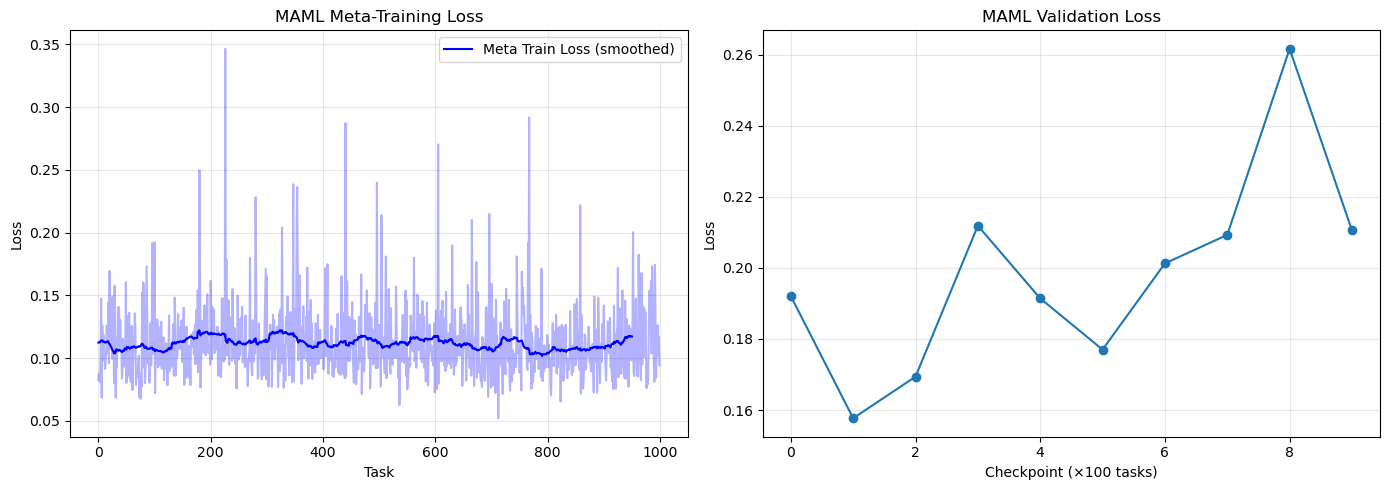

In [6]:
# CELL 5: Training Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['meta_train_loss'], alpha=0.3, color='blue')
# Smoothed version (rolling average)
window = 50
if len(history['meta_train_loss']) >= window:
    smoothed = np.convolve(history['meta_train_loss'],
                           np.ones(window)/window, mode='valid')
    axes[0].plot(smoothed, color='blue', label='Meta Train Loss (smoothed)')
axes[0].set_xlabel('Task')
axes[0].set_ylabel('Loss')
axes[0].set_title('MAML Meta-Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['meta_val_loss'], marker='o')
axes[1].set_xlabel('Checkpoint (×100 tasks)')
axes[1].set_ylabel('Loss')
axes[1].set_title('MAML Validation Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'maml_training_curve.png'), dpi=150)
plt.show()

In [7]:
# CELL 6: K-Shot Evaluation
k_shot_results = trainer.evaluate_k_shot(
    k_values=Config.K_SHOT_VALUES,
    num_tasks=50,
)

print_kshot_results(k_shot_results, Config.K_SHOT_VALUES, "MAML K-SHOT RESULTS")
save_kshot_results(k_shot_results, Config.RESULTS_DIR, 'maml_kshot_results.json')


Evaluating MAML at k=1...
  Task 5/50: DICE = 0.8570
  Task 10/50: DICE = 0.6883
  Task 15/50: DICE = 0.8791
  Task 20/50: DICE = 0.7088
  Task 25/50: DICE = 0.7109
  Task 30/50: DICE = 0.6372
  Task 35/50: DICE = 0.6998
  Task 40/50: DICE = 0.8145
  Task 45/50: DICE = 0.7246
  Task 50/50: DICE = 0.8049
✓ k=1: DICE = 0.7745 ± 0.0700

Evaluating MAML at k=5...
  Task 5/50: DICE = 0.7958
  Task 10/50: DICE = 0.8535
  Task 15/50: DICE = 0.7571
  Task 20/50: DICE = 0.7787
  Task 25/50: DICE = 0.8477
  Task 30/50: DICE = 0.8973
  Task 35/50: DICE = 0.7675
  Task 40/50: DICE = 0.8166
  Task 45/50: DICE = 0.8890
  Task 50/50: DICE = 0.8362
✓ k=5: DICE = 0.7996 ± 0.0669

Evaluating MAML at k=10...
  Task 5/50: DICE = 0.7272
  Task 10/50: DICE = 0.8230
  Task 15/50: DICE = 0.8780
  Task 20/50: DICE = 0.7840
  Task 25/50: DICE = 0.8105
  Task 30/50: DICE = 0.7427
  Task 35/50: DICE = 0.8558
  Task 40/50: DICE = 0.9091
  Task 45/50: DICE = 0.7728
  Task 50/50: DICE = 0.7963
✓ k=10: DICE = 0.8000